# **REGRESIÓN LINEAL**

**1. Importación de librerías**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**2. Lectura del conjunto de datos**

In [6]:
df = pd.read_csv("/content/datos_procesados.txt",sep = " ")
X = df["n_equipos_afectados"]
y = df["coste"]

**3. Visualización del conjunto de datos**

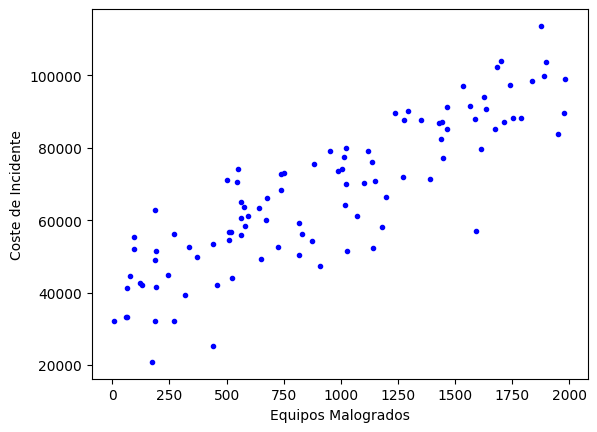

In [7]:
plt.plot(X,y,"b.")
plt.xlabel("Equipos Malogrados")
plt.ylabel("Coste de Incidente")
plt.show()

**4. División del conjunto de datos**

In [8]:
#Separamos el conjunto de datos en 60% para train_set y 40% test_set
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.4, random_state=1)

In [9]:
print("Longitud de datos de entrenamiento: (%60)", len(train_set))
print("Longitud de datos de test: (%40)", len(test_set))
print("Longitud de datos total:", len(df))

Longitud de datos de entrenamiento: (%60) 60
Longitud de datos de test: (%40) 40
Longitud de datos total: 100


**5. Entrenamiento**

In [10]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(train_set["n_equipos_afectados"].values.reshape(-1,1),train_set["coste"].values)

LinearRegression()

In [11]:
#Parametro theta 0
lin_reg.intercept_

np.float64(38329.955762537254)

In [12]:
#Parametro theta 1
lin_reg.coef_

array([30.80729095])

In [13]:
x_min_max = np.array([[train_set["n_equipos_afectados"].min()] ,[train_set["n_equipos_afectados"].max() ]])
y_train_pred = lin_reg.predict(x_min_max)
x_min_max , y_train_pred

(array([[   9],
        [1978]]),
 array([38607.22138109, 99266.77726156]))

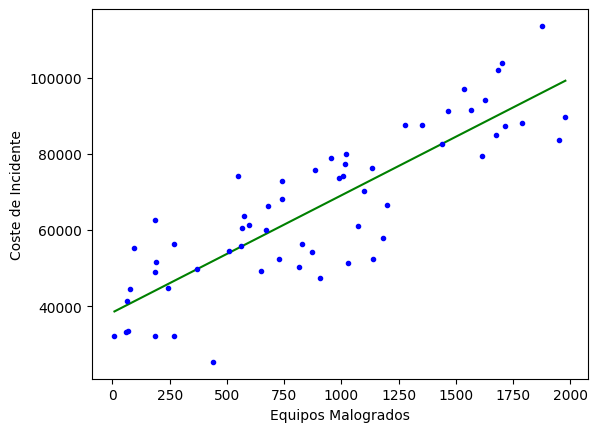

In [14]:
plt.plot(x_min_max,y_train_pred,"-g")
plt.plot(train_set["n_equipos_afectados"],train_set["coste"],"b.")
plt.xlabel("Equipos Malogrados")
plt.ylabel("Coste de Incidente")
plt.show()

In [15]:
x_new = np.array([[30]])
coste = lin_reg.predict(x_new)
print("El coste del incidente seria: ", coste[0])

El coste del incidente seria:  39254.17449103609


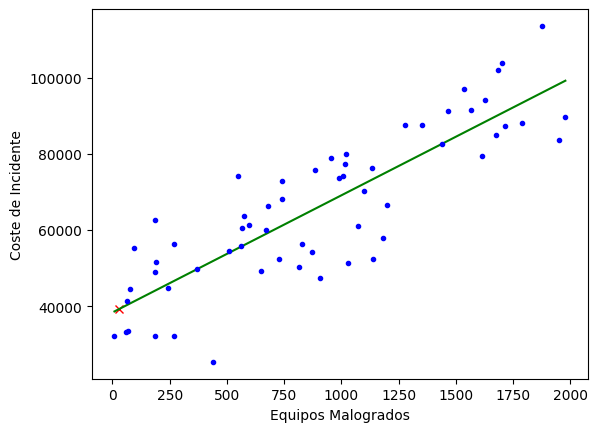

In [16]:
plt.plot(x_new,coste,"rx")
plt.plot(x_min_max,y_train_pred,"-g")
plt.plot(train_set["n_equipos_afectados"],train_set["coste"],"b.")
plt.xlabel("Equipos Malogrados")
plt.ylabel("Coste de Incidente")
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Variables reales y predichas
X_test = test_set[["n_equipos_afectados"]].values
y_test = test_set["coste"].values
y_pred = lin_reg.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Error Absoluto Medio): {mae:.2f}")
print(f"MSE  (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"R²   (Coeficiente de Determinación): {r2:.4f}")

MAE  (Error Absoluto Medio): 6765.53
MSE  (Error Cuadrático Medio): 85029938.61
RMSE (Raíz del Error Cuadrático Medio): 9221.17
R²   (Coeficiente de Determinación): 0.7895


# **REGRESIÓN LOGÍSTICA**

In [23]:
#@title Recursos Adicionales
from matplotlib import pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec

def plot_decision_boundary(X, y, clf):
    mins = X.min(axis=0) - 0.5
    maxs = X.max(axis=0) + 0.5

    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 71),
                     np.linspace(mins[1], maxs[1], 81))
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z[:, 1].reshape(xx.shape)

    gs = gridspec.GridSpec(1, 2)
    gs.update(hspace=0.8)

    ax = plt.subplot(gs[0])
    ax.contourf(xx, yy, Z, cmap="RdBu", alpha=0.5)
    ax.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.')
    ax.plot(X[:, 0][y==0], X[:, 1][y==0], 'b.')

    ax = plt.subplot(gs[1])
    ax.contour(xx, yy, Z, [0.5], colors='k')
    ax.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.')
    ax.plot(X[:, 0][y==0], X[:, 1][y==0], 'b.')

**1. Importación del conjunto de datos**

In [24]:
#Generamos un conjunto de datos más sencillo
from sklearn import datasets
import numpy as np
iris = datasets.load_iris()
X = iris["data"][:,(2,3)]
y = (iris["target"]==2).astype(np.int32)

**2. Visualización del conjunto de datos**

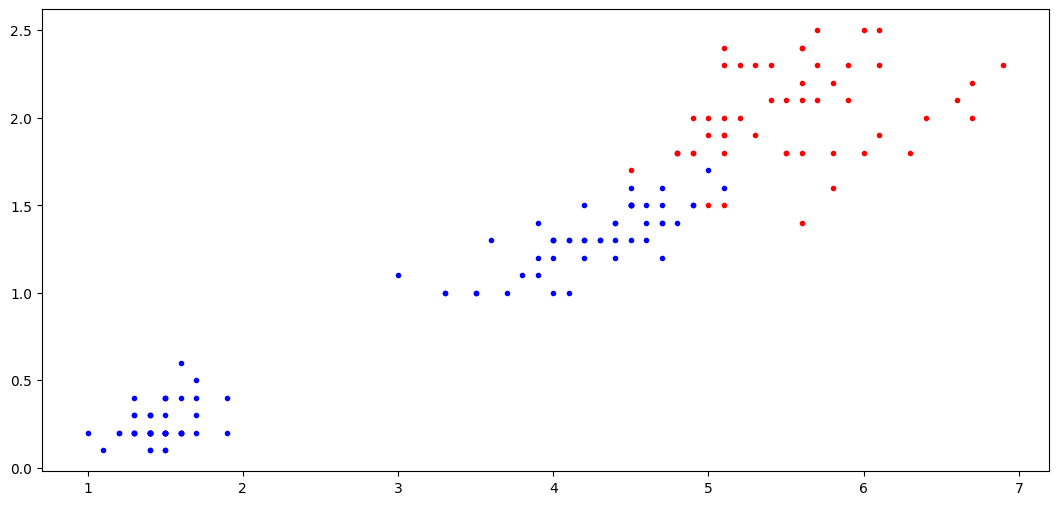

In [25]:
#representación gráfica del conjunto generado
plt.figure(figsize=(13,6))
plt.scatter(X[:,0][y==0],X[:,1][y==0], c = "b", marker = "." )
plt.scatter(X[:,0][y==1],X[:,1][y==1], c = "r", marker = "." )
plt.show()

**3. División del conjunto de datos**

In [35]:
# Dividir los datos en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**3. Entrenamiento**

In [37]:
# Crear el modelo de Regresión Logística
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

# Entrenar el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)


LogisticRegression()

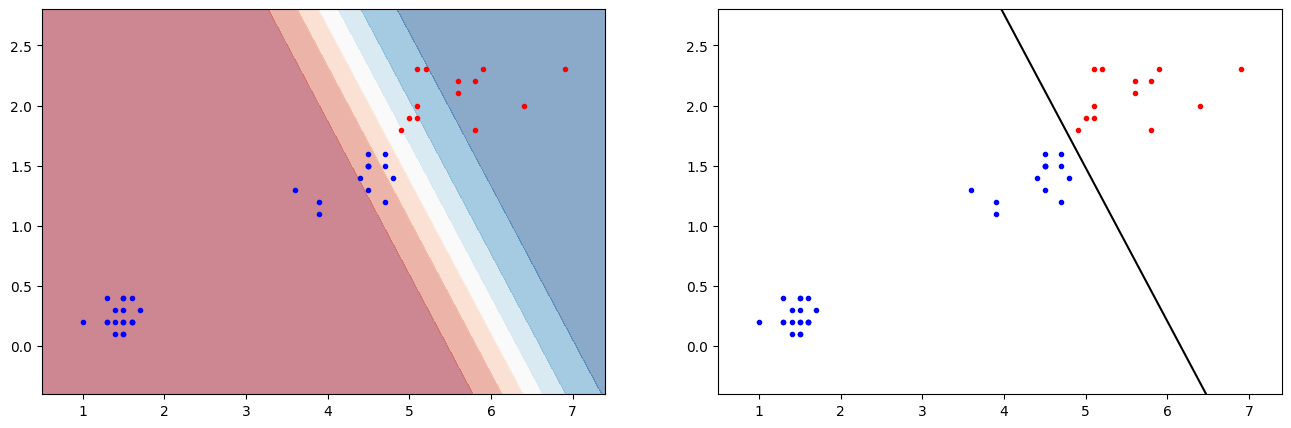

In [43]:
# Graficar la frontera de decisión con la función definida previamente
plt.figure(figsize=(16,5))
plot_decision_boundary(X_test, y_test, clf)
# Mostrar el gráfico
plt.show()

In [42]:
from sklearn.metrics import precision_score, recall_score

# Realizar predicciones con el conjunto de prueba
y_pred = clf.predict(X_test)

# Calcular las métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Mostrar los resultados
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 1.0000
Recall: 1.0000


## **SUPPORT VECTOR MACHINE**

In [27]:
# Importamos las librerías necesarias
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [28]:
# Cargar el conjunto de datos iris y seleccionar características
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # Ancho y largo del pétalo
y = (iris["target"] == 2).astype(np.int32)  # Clase "virginica" vs otras

In [29]:
# Dividir los datos en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
# Crear el modelo SVM con kernel polinomial y probabilidad habilitada
from sklearn.svm import SVC
svm_poly = SVC(kernel='poly', degree=3, gamma='scale', probability=True)

In [31]:
# Entrenar el modelo
svm_poly.fit(X_train, y_train)

SVC(kernel='poly', probability=True)

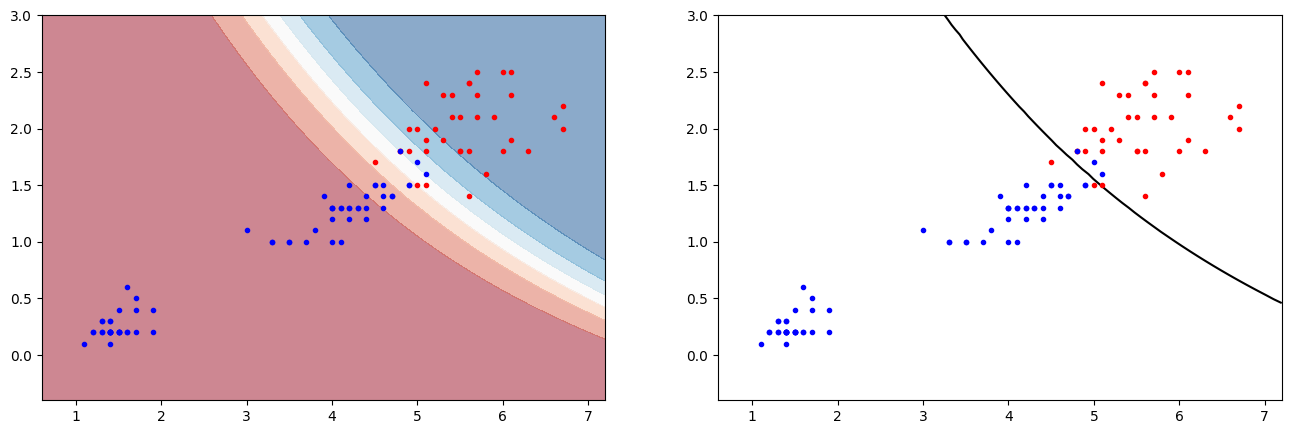

In [34]:
# Graficar la frontera de decisión con la función definida previamente
plt.figure(figsize=(16,5))
plot_decision_boundary(X_train, y_train, svm_poly)
# Mostrar el gráfico
plt.show()

In [44]:
from sklearn.metrics import precision_score, recall_score

# Realizar predicciones con el conjunto de prueba
y_pred = svm_poly.predict(X_test)

# Calcular las métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Mostrar los resultados
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 1.0000
Recall: 1.0000
